In [1]:
import os
import glob

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="paper")

# ============================================================
# LOAD RESULTS
# ============================================================

RESULTS_PATH = "results/best_configs_500"

files = glob.glob(os.path.join(RESULTS_PATH, "meeting_n500_array_20497915.csv"))

print("Loaded files:")
for f in files:
    print(os.path.basename(f))

dfs = []

for file in files:
    df_tmp = pd.read_csv(file)

    # source filename
    df_tmp["source_file"] = os.path.basename(file)

    dfs.append(df_tmp)

df_meeting = pd.concat(dfs, ignore_index=True)

print(f"\nTotal rows: {len(df_meeting)}")

display(df_meeting.head())

print("\nColumns:")
print(df_meeting.columns.tolist())

Loaded files:
meeting_n500_array_20497915.csv

Total rows: 25


,array_task_id,topology,number_of_islands,number_of_migrants,migration_interval,z_star,n_steps,r0,r1,gamma,build_target_ratio,seed,average,best,source_file
0,1,meeting,500,5,5,15,1000,0.002,1.0,0.010,0.8,123,64.945940,43.862222,meeting_n500_array_20497915.csv
1,0,meeting,500,5,5,15,1000,0.002,1.0,0.010,0.8,123,64.436767,43.862222,meeting_n500_array_20497915.csv
2,2,meeting,500,5,5,15,1000,0.002,1.0,0.010,0.8,123,65.277625,43.862222,meeting_n500_array_20497915.csv
3,3,meeting,500,5,5,15,1000,0.002,1.0,0.010,0.8,123,62.676881,48.859671,meeting_n500_array_20497915.csv
4,5,meeting,500,5,5,15,1000,0.002,1.0,0.005,0.8,123,57.381621,47.392827,meeting_n500_array_20497915.csv



Columns:
['array_task_id', 'topology', 'number_of_islands', 'number_of_migrants', 'migration_interval', 'z_star', 'n_steps', 'r0', 'r1', 'gamma', 'build_target_ratio', 'seed', 'average', 'best', 'source_file']


In [2]:
# tworzymy nową kolumnę config_id do łatwego grupowania wyników

config_cols_meeting = [
    "number_of_islands",
    "migration_interval",
    "z_star",
    "n_steps",
    "r0",
    "r1",
    "gamma"

]

df_meeting["config_id"] = (
    df_meeting[config_cols_meeting]
    .astype(str)
    .agg("_".join, axis=1)
)

In [3]:
meeting_summary = (
    df_meeting
    .groupby(["config_id","topology","number_of_islands"], as_index=False)
    .agg(
        mean_best=("best", "mean"),
        std_best=("best", "std"),
        min_best=("best", "min"),
        max_best=("best", "max"),
        median_best=("best", "median"),
        mean_avg=("average", "mean"),
        std_avg=("average", "std"),
        min_avg=("average", "min"),
        max_avg=("average", "max"),
        median_avg=("average", "median"),
    )
)

meeting_summary.sort_values("mean_best")

,config_id,topology,number_of_islands,mean_best,std_best,min_best,max_best,median_best,mean_avg,std_avg,min_avg,max_avg,median_avg
4,500_5_20_2000_0.001_1.0_0.02,meeting,500,45.128333,1.903344,43.082095,47.287153,44.428223,58.239325,2.815900,54.777928,61.045738,58.214707
3,500_5_15_1000_0.002_1.0_0.01,meeting,500,45.567833,2.392391,43.862222,48.859671,43.862222,62.965918,3.219901,57.492378,65.277625,64.436767
2,500_5_15_1000_0.002_1.0_0.005,meeting,500,50.083825,3.889430,47.392827,56.781680,49.038141,61.249674,7.923407,55.762027,75.221110,58.632028
1,500_5_10_1000_0.001_1.0_0.005,meeting,500,52.665642,8.796639,40.227287,59.774653,57.042663,67.180208,9.341093,54.061145,74.073823,73.656600
0,500_5_10_1000_0.0005_1.0_0.005,meeting,500,53.921164,3.804516,50.313937,59.527518,52.485103,69.842962,4.194822,63.261311,74.730975,70.594481


In [4]:

from scipy.stats import kruskal

groups = [
    group["best"].values
    for _, group in df_meeting.groupby("config_id")
]

stat, p = kruskal(*groups)

print(stat, p)

11.488888888888885 0.02158567618790218


## Scale-free

In [5]:
import os
import glob

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid")

# ============================================================
# LOAD RESULTS
# ============================================================

RESULTS_PATH = "results/best_configs_500"

files = glob.glob(os.path.join(RESULTS_PATH, "scale_free_n500_array_20495465.csv"))

print("Loaded files:")
for f in files:
    print(os.path.basename(f))

dfs = []

for file in files:
    df_tmp = pd.read_csv(file)

    # source filename
    df_tmp["source_file"] = os.path.basename(file)

    dfs.append(df_tmp)

df_scale_free = pd.concat(dfs, ignore_index=True)


print(f"\nTotal rows: {len(df_meeting)}")

display(df_scale_free.head())

print("\nColumns:")
print(df_scale_free.columns.tolist())

Loaded files:
scale_free_n500_array_20495465.csv

Total rows: 25


,array_task_id,topology,number_of_islands,number_of_migrants,migration_interval,m0,m,seed,average,best,source_file
0,2,scale_free,500,5,5,60,59,123,84.664499,19.862052,scale_free_n500_array_20495465.csv
1,1,scale_free,500,5,5,60,59,123,85.447227,20.217417,scale_free_n500_array_20495465.csv
2,3,scale_free,500,5,5,60,59,123,85.139621,23.534009,scale_free_n500_array_20495465.csv
3,0,scale_free,500,5,5,60,59,123,80.984707,18.462327,scale_free_n500_array_20495465.csv
4,4,scale_free,500,5,5,60,59,123,77.396956,18.453630,scale_free_n500_array_20495465.csv



Columns:
['array_task_id', 'topology', 'number_of_islands', 'number_of_migrants', 'migration_interval', 'm0', 'm', 'seed', 'average', 'best', 'source_file']


In [6]:
config_cols_scale = [
    "number_of_islands",
    "migration_interval",
    "m0",
    "m"
]

df_scale_free["config_id"] = (
    df_scale_free[config_cols_scale]
    .astype(str)
    .agg("_".join, axis=1)
)

In [7]:
scale_free_summary = (
    df_scale_free
    .groupby(["config_id","topology","number_of_islands"], as_index=False)
    .agg(
        mean_best=("best", "mean"),
        std_best=("best", "std"),
        min_best=("best", "min"),
        max_best=("best", "max"),
        median_best=("best", "median"),
        mean_avg=("average", "mean"),
        std_avg=("average", "std"),
        min_avg=("average", "min"),
        max_avg=("average", "max"),
        median_avg=("average", "median"),
    )
)

scale_free_summary.sort_values("mean_best")

,config_id,topology,number_of_islands,mean_best,std_best,min_best,max_best,median_best,mean_avg,std_avg,min_avg,max_avg,median_avg
2,500_5_35_31,scale_free,500,19.156587,1.661546,16.704060,21.059561,18.990321,79.304340,2.180533,76.629697,82.374521,78.870616
4,500_5_60_59,scale_free,500,20.105887,2.076966,18.453630,23.534009,19.862052,82.726602,3.479197,77.396956,85.447227,84.664499
0,500_5_25_25,scale_free,500,21.007104,2.202425,17.850363,23.393910,21.264895,86.959775,7.353611,78.426119,93.367256,90.850257
3,500_5_50_43,scale_free,500,21.283799,1.904487,18.062331,22.765560,22.057939,83.128471,10.333178,72.479823,95.394016,78.918797
1,500_5_30_26,scale_free,500,22.169797,2.650100,19.653448,26.251421,22.229399,87.750215,10.220256,78.220743,100.346122,83.397569


In [8]:
groups = [
    group["best"].values
    for _, group in df_scale_free.groupby("config_id")
]

stat, p = kruskal(*groups)

print(stat, p)

4.349538461538458 0.3607629140132263


In [9]:
groups

[array([23.39391049, 17.8503635 , 21.26489469, 22.59419771, 19.93215202]),
 array([26.25142067, 22.22939872, 19.65344806, 19.98316952, 22.73155009]),
 array([20.26379626, 18.99032059, 21.05956086, 18.76519645, 16.70405963]),
 array([22.05793876, 22.42588551, 18.06233055, 22.76556011, 21.10728144]),
 array([19.86205212, 20.21741716, 23.53400883, 18.46232669, 18.45363034])]

# Complete

In [10]:
RESULTS_PATH = "results/best_configs_500"

files = glob.glob(os.path.join(RESULTS_PATH, "complete_n500_array_20500075.csv"))

print("Loaded files:")
for f in files:
    print(os.path.basename(f))

dfs = []

for file in files:
    df_tmp = pd.read_csv(file)

    # source filename
    df_tmp["source_file"] = os.path.basename(file)

    dfs.append(df_tmp)

df_complete = pd.concat(dfs, ignore_index=True)

print(f"\nTotal rows: {len(df_complete)}")

display(df_complete.head())

Loaded files:
complete_n500_array_20500075.csv

Total rows: 20


,array_task_id,topology,number_of_islands,number_of_migrants,migration_interval,average,best,source_file
0,1,complete,500,5,5,59.102739,37.124082,complete_n500_array_20500075.csv
1,0,complete,500,5,5,59.407617,37.274930,complete_n500_array_20500075.csv
2,2,complete,500,5,5,60.912476,37.274930,complete_n500_array_20500075.csv
3,3,complete,500,5,5,61.749603,37.782316,complete_n500_array_20500075.csv
4,4,complete,500,5,5,57.451546,42.555667,complete_n500_array_20500075.csv


## Analiza statystyczna pomiędzy topologiami

In [11]:
# bierzemy wartosci dla wszystkich top5 konfiguracji
meeting_values = df_meeting["best"]
scale_free_values = df_scale_free["best"]
complete_values = df_complete["best"]

In [12]:
stat, p = kruskal(
    meeting_values,
    scale_free_values,
    complete_values,
)

print(stat, p)

54.664822553548944 1.3479835904428975e-12


In [13]:
import scikit_posthocs as sp

df_compare = pd.concat([
    df_meeting,
    df_scale_free,
    df_complete
], ignore_index=True)

posthoc = sp.posthoc_dunn(
    df_compare,
    val_col="best",
    group_col="topology",
    p_adjust="holm"
)

print(posthoc)

            complete       meeting    scale_free
complete    1.000000  7.620911e-03  4.260230e-05
meeting     0.007621  1.000000e+00  6.458923e-13
scale_free  0.000043  6.458923e-13  1.000000e+00


In [14]:
df_compare.groupby("topology")["best"].agg(
    ["mean","median","std"]
)

,mean,median,std
topology,,,
complete,42.290920,42.077754,4.354745
meeting,49.473359,47.392827,5.728983
scale_free,20.744635,20.263796,2.207035


## Tylko top1 konfiguracje meeting i scale_free

In [15]:
# bierzemy top1 konfigurację
best_config_id_meeting = (
    meeting_summary
    .sort_values("mean_best")
    .iloc[0]["config_id"]
)

top1_meeting = df_meeting[
    df_meeting["config_id"] == best_config_id_meeting
]

In [16]:
best_config_id_meeting

'500_5_20_2000_0.001_1.0_0.02'

In [17]:
# bierzemy top1 konfigurację
best_config_id_scale = (
    scale_free_summary
    .sort_values("mean_best")
    .iloc[0]["config_id"]
)

top1_scale_free = df_scale_free[
    df_scale_free["config_id"] == best_config_id_scale
]

top1_scale_free

,array_task_id,topology,number_of_islands,number_of_migrants,migration_interval,m0,m,seed,average,best,source_file,config_id
5,5,scale_free,500,5,5,35,31,123,80.384169,20.263796,scale_free_n500_array_20495465.csv,500_5_35_31
6,6,scale_free,500,5,5,35,31,123,76.629697,18.990321,scale_free_n500_array_20495465.csv,500_5_35_31
7,7,scale_free,500,5,5,35,31,123,82.374521,21.059561,scale_free_n500_array_20495465.csv,500_5_35_31
8,8,scale_free,500,5,5,35,31,123,78.262699,18.765196,scale_free_n500_array_20495465.csv,500_5_35_31
9,9,scale_free,500,5,5,35,31,123,78.870616,16.704060,scale_free_n500_array_20495465.csv,500_5_35_31


In [18]:
stat, p = kruskal(
    top1_meeting['best'],
    top1_scale_free['best'],
    complete_values,
)

print(stat, p)

15.010017809439004 0.0005503209498680058


In [19]:
df_compare = pd.concat([
    top1_meeting,
    top1_scale_free,
    df_complete
], ignore_index=True)

posthoc = sp.posthoc_dunn(
    df_compare,
    val_col="best",
    group_col="topology",
    p_adjust="holm"
)

print(posthoc)

            complete   meeting  scale_free
complete    1.000000  0.088296    0.004310
meeting     0.088296  1.000000    0.000484
scale_free  0.004310  0.000484    1.000000


In [20]:
from cliffs_delta import cliffs_delta

delta, interpretation = cliffs_delta(
    df_complete['best'],
    top1_meeting['best'],
)
print(delta)
print(interpretation)

-0.6
large


In [21]:
top1_meeting

,array_task_id,topology,number_of_islands,number_of_migrants,migration_interval,z_star,n_steps,r0,r1,gamma,build_target_ratio,seed,average,best,source_file,config_id
15,15,meeting,500,5,5,20,2000,0.001,1.0,0.02,0.8,123,54.777928,43.844040,meeting_n500_array_20497915.csv,500_5_20_2000_0.001_1.0_0.02
16,16,meeting,500,5,5,20,2000,0.001,1.0,0.02,0.8,123,58.214707,44.428223,meeting_n500_array_20497915.csv,500_5_20_2000_0.001_1.0_0.02
17,17,meeting,500,5,5,20,2000,0.001,1.0,0.02,0.8,123,61.045738,47.000153,meeting_n500_array_20497915.csv,500_5_20_2000_0.001_1.0_0.02
18,18,meeting,500,5,5,20,2000,0.001,1.0,0.02,0.8,123,60.990391,47.287153,meeting_n500_array_20497915.csv,500_5_20_2000_0.001_1.0_0.02
24,19,meeting,500,5,5,20,2000,0.001,1.0,0.02,0.8,123,56.167858,43.082095,meeting_n500_array_20497915.csv,500_5_20_2000_0.001_1.0_0.02


In [22]:
param_cols = top1_meeting.columns[2:12] # ignoruje pierwsze 2 i ostatnie 4 kolumny
out = top1_meeting[param_cols].copy()

# Dla częsci wcześniejszych eksperymentów nie było zapisu tych parametrów, więc dodałem je ręcznie. W nowszej wersji zapisują się automatycznie
# out["build_target_ratio"] = 0.8
# out["seed"] = 123

# powtarzamy każdą konfigurację parametrów 5-krotnie
out_repeated = out.loc[out.index.repeat(2)].reset_index(drop=True)

out_repeated.to_csv(
    "top1_meeting_new.txt",
    sep=" ",
    header=False,
    index=False
)

In [23]:
param_cols = top1_scale_free.columns[2:7] # ignoruje pierwsze 2 i ostatnie 5 kolumn

out = top1_scale_free[param_cols].copy()
out["seed"] = 123

out_scale_free = out.loc[out.index.repeat(2)].reset_index(drop=True)

out_scale_free.to_csv(
    "top1_scale_new.txt",
    sep=" ",
    header=False,
    index=False
)

## Dodajemy 20 powtórzeń dla top1 konfiguracji

In [24]:
file = glob.glob(os.path.join(RESULTS_PATH, "scale_free_n500_array_20500054.csv"))
print(file)
df_tmp = pd.read_csv(file[0])

# source filename
df_tmp["source_file"] = os.path.basename(file[0])

df_scale_free = df_tmp.copy()

df_scale_free["config_id"] = (
    df_scale_free[config_cols_scale]
    .astype(str)
    .agg("_".join, axis=1)
)

top1_scale_free = df_scale_free[
    df_scale_free["config_id"] == best_config_id_scale
]

print("\nColumns:")
print(df_scale_free.columns.tolist())

top1_scale_free.drop_duplicates()

['results/best_configs_500/scale_free_n500_array_20500054.csv']

Columns:
['array_task_id', 'topology', 'number_of_islands', 'number_of_migrants', 'migration_interval', 'm0', 'm', 'seed', 'average', 'best', 'source_file', 'config_id']


,array_task_id,topology,number_of_islands,number_of_migrants,migration_interval,m0,m,seed,average,best,source_file,config_id
0,1,scale_free,500,5,5,35,31,123,80.736700,19.705070,scale_free_n500_array_20500054.csv,500_5_35_31
1,3,scale_free,500,5,5,35,31,123,80.472573,19.705070,scale_free_n500_array_20500054.csv,500_5_35_31
2,2,scale_free,500,5,5,35,31,123,79.884966,20.845396,scale_free_n500_array_20500054.csv,500_5_35_31
3,0,scale_free,500,5,5,35,31,123,78.291767,16.904922,scale_free_n500_array_20500054.csv,500_5_35_31
4,4,scale_free,500,5,5,35,31,123,83.866839,18.448115,scale_free_n500_array_20500054.csv,500_5_35_31
5,6,scale_free,500,5,5,35,31,123,76.605029,24.091969,scale_free_n500_array_20500054.csv,500_5_35_31
6,7,scale_free,500,5,5,35,31,123,80.342804,18.379884,scale_free_n500_array_20500054.csv,500_5_35_31
7,5,scale_free,500,5,5,35,31,123,74.356141,19.416458,scale_free_n500_array_20500054.csv,500_5_35_31
8,8,scale_free,500,5,5,35,31,123,76.363501,19.862316,scale_free_n500_array_20500054.csv,500_5_35_31
9,9,scale_free,500,5,5,35,31,123,82.924082,19.324261,scale_free_n500_array_20500054.csv,500_5_35_31


In [25]:
file = glob.glob(os.path.join(RESULTS_PATH, "meeting_n500_array_20500107.csv"))
print(file)
df_tmp = pd.read_csv(file[0])

# source filename
df_tmp["source_file"] = os.path.basename(file[0])

df_meeting = df_tmp.copy()

df_meeting["config_id"] = (
    df_meeting[config_cols_meeting]
    .astype(str)
    .agg("_".join, axis=1)
)

print("\nColumns:")
print(df_meeting.columns.tolist())

top1_meeting = df_meeting[df_meeting["config_id"] == best_config_id_meeting]

top1_meeting.drop_duplicates()

['results/best_configs_500/meeting_n500_array_20500107.csv']

Columns:
['array_task_id', 'topology', 'number_of_islands', 'number_of_migrants', 'migration_interval', 'z_star', 'n_steps', 'r0', 'r1', 'gamma', 'build_target_ratio', 'seed', 'average', 'best', 'source_file', 'config_id']


,array_task_id,topology,number_of_islands,number_of_migrants,migration_interval,z_star,n_steps,r0,r1,gamma,build_target_ratio,seed,average,best,source_file,config_id
0,3,meeting,500,5,5,20,2000,0.001,1.0,0.02,0.8,123,54.109538,37.294479,meeting_n500_array_20500107.csv,500_5_20_2000_0.001_1.0_0.02
1,0,meeting,500,5,5,20,2000,0.001,1.0,0.02,0.8,123,61.239845,40.099496,meeting_n500_array_20500107.csv,500_5_20_2000_0.001_1.0_0.02
2,1,meeting,500,5,5,20,2000,0.001,1.0,0.02,0.8,123,55.899318,37.281817,meeting_n500_array_20500107.csv,500_5_20_2000_0.001_1.0_0.02
3,2,meeting,500,5,5,20,2000,0.001,1.0,0.02,0.8,123,56.665015,38.876094,meeting_n500_array_20500107.csv,500_5_20_2000_0.001_1.0_0.02
4,4,meeting,500,5,5,20,2000,0.001,1.0,0.02,0.8,123,51.675822,37.492602,meeting_n500_array_20500107.csv,500_5_20_2000_0.001_1.0_0.02
5,6,meeting,500,5,5,20,2000,0.001,1.0,0.02,0.8,123,57.931048,43.670399,meeting_n500_array_20500107.csv,500_5_20_2000_0.001_1.0_0.02
6,5,meeting,500,5,5,20,2000,0.001,1.0,0.02,0.8,123,62.466132,52.644246,meeting_n500_array_20500107.csv,500_5_20_2000_0.001_1.0_0.02
7,7,meeting,500,5,5,20,2000,0.001,1.0,0.02,0.8,123,62.383592,47.107564,meeting_n500_array_20500107.csv,500_5_20_2000_0.001_1.0_0.02
8,8,meeting,500,5,5,20,2000,0.001,1.0,0.02,0.8,123,63.398478,44.960214,meeting_n500_array_20500107.csv,500_5_20_2000_0.001_1.0_0.02
9,10,meeting,500,5,5,20,2000,0.001,1.0,0.02,0.8,123,54.403313,39.027237,meeting_n500_array_20500107.csv,500_5_20_2000_0.001_1.0_0.02


In [26]:
df_compare = pd.concat([
    top1_meeting,
    top1_scale_free,
    df_complete
], ignore_index=True)

df_compare.groupby("topology").agg(
            mean_best=("best", "mean"),
            std_best=("best", "std"),
            median_best=("best", "median"),
            mean_average=("average", "mean"),
            std_average=("average", "std"),

        )



,mean_best,std_best,median_best,mean_average,std_average
topology,,,,,
complete,42.290920,4.354745,42.077754,59.499713,4.657617
meeting,43.892197,4.961688,43.179684,59.330722,4.437211
scale_free,20.183630,1.959215,19.957290,80.313528,4.576651


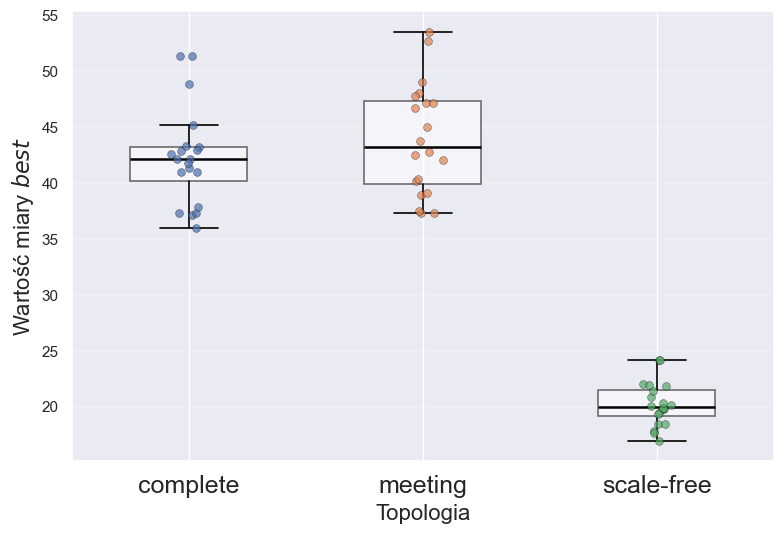

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BEST_COL = "best"
OUTPUT_PATH = "extended_500_top1_boxplot.pdf"

meeting_plot = top1_meeting[[BEST_COL]].copy()
meeting_plot["topology"] = "meeting"

scale_free_plot = top1_scale_free[[BEST_COL]].copy()
scale_free_plot["topology"] = "scale-free"

complete_plot = df_complete[[BEST_COL]].copy()
complete_plot["topology"] = "complete"

plot_df = pd.concat(
    [complete_plot, meeting_plot, scale_free_plot],
    ignore_index=True
).dropna(subset=[BEST_COL])

order = ["complete", "meeting", "scale-free"]

values = [
    plot_df.loc[
        plot_df["topology"] == topology,
        BEST_COL
    ].to_numpy()
    for topology in order
]

fig, ax = plt.subplots(figsize=(8, 5.5))

ax.boxplot(
    values,
    tick_labels=order,
    widths=0.5,
    patch_artist=True,
    showmeans=False,
    showfliers=False,
    # punkty są i tak pokazane osobno
    boxprops={
        "facecolor": "white",
        "edgecolor": "black",
        "linewidth": 1.2,
        "alpha": 0.55,
    },
    medianprops={
        "color": "black",
        "linewidth": 1.8,
    },
    whiskerprops={
        "color": "black",
        "linewidth": 1.2,
    },
    capprops={
        "color": "black",
        "linewidth": 1.2,
    },
)

# Punkty z niewielkim przesunięciem poziomym
rng = np.random.default_rng(42)

for position, group_values in enumerate(values, start=1):
    jitter = rng.normal(
        loc=0,
        scale=0.04,
        size=len(group_values)
    )

    ax.scatter(
        np.full(len(group_values), position) + jitter,
        group_values,
        alpha=0.7,
        s=32,
        zorder=3,
        edgecolors="black",
        linewidths=0.3,
    )

ax.set_xlabel("Topologia", size = 16)
ax.set_ylabel(r"Wartość miary $\it{best}$", size = 16)
ax.grid(axis="y", alpha=0.25)
ax.tick_params(axis="x", labelsize=18)

fig.tight_layout()
fig.savefig(
    OUTPUT_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [28]:
df_complete

,array_task_id,topology,number_of_islands,number_of_migrants,migration_interval,average,best,source_file
0,1,complete,500,5,5,59.102739,37.124082,complete_n500_array_20500075.csv
1,0,complete,500,5,5,59.407617,37.274930,complete_n500_array_20500075.csv
2,2,complete,500,5,5,60.912476,37.274930,complete_n500_array_20500075.csv
3,3,complete,500,5,5,61.749603,37.782316,complete_n500_array_20500075.csv
4,4,complete,500,5,5,57.451546,42.555667,complete_n500_array_20500075.csv
5,5,complete,500,5,5,57.369731,42.077754,complete_n500_array_20500075.csv
6,6,complete,500,5,5,57.246951,42.077754,complete_n500_array_20500075.csv
7,7,complete,500,5,5,62.767783,43.287419,complete_n500_array_20500075.csv
8,8,complete,500,5,5,56.931575,41.283740,complete_n500_array_20500075.csv
9,10,complete,500,5,5,56.628642,40.931798,complete_n500_array_20500075.csv


In [29]:
stat, p = kruskal(
    top1_meeting['best'],
    top1_scale_free['best'],
    df_complete['best']
)

print(stat, p)

39.847379536486436 2.2245976519968992e-09


In [30]:
posthoc = sp.posthoc_dunn(
    df_compare,
    val_col="best",
    group_col="topology",
    p_adjust="holm"
)

print(posthoc)

                complete       meeting    scale_free
complete    1.000000e+00  4.800525e-01  7.575062e-07
meeting     4.800525e-01  1.000000e+00  2.168190e-08
scale_free  7.575062e-07  2.168190e-08  1.000000e+00


<Axes: xlabel='topology', ylabel='best'>

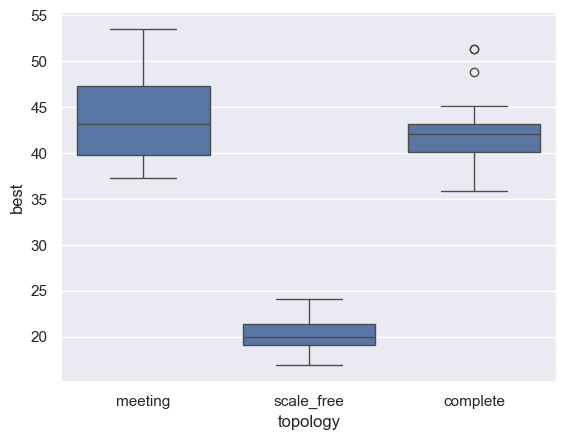

In [31]:
sns.boxplot(
    data=df_compare,
    x="topology",
    y="best"
)

In [32]:
from cliffs_delta import cliffs_delta

delta, interpretation = cliffs_delta(
    top1_scale_free['best'],
    top1_meeting['best'],
)

print(delta)
print(interpretation)

-1.0
large


In [33]:
delta, interpretation = cliffs_delta(
    top1_meeting['best'],
    df_complete['best'],
)

print(delta)
print(interpretation)

0.195
small
